In [2]:
import numpy as np
import pandas as pd

np.random.seed(0)

# -----------------------------
# PARÁMETROS
# -----------------------------
n_hours = 2000
streets = [
    "Castellana", "GranVia", "Alcala", "Princesa",
    "Atocha", "BravoMurillo", "Goya", "Velazquez"
]

t = np.arange(n_hours)
data = {}

# -----------------------------
# TRÁFICO HORARIO REALISTA
# -----------------------------
for street in streets:
    base = np.random.uniform(400, 800)
    daily_pattern = 120 * np.sin(2 * np.pi * t / 24)
    noise = np.random.normal(0, 40, n_hours)
    data[street] = base + daily_pattern + noise

# Variables externas
data["lluvia"] = np.random.binomial(1, 0.2, n_hours)
data["festivo"] = np.random.binomial(1, 0.1, n_hours)

df = pd.DataFrame(data)
df.head()

,Castellana,GranVia,Alcala,Princesa,Atocha,BravoMurillo,Goya,Velazquez,lluvia,festivo
0,649.189071,476.981496,720.669900,566.996183,485.385339,779.617334,468.189589,731.124057,0,0
1,712.700236,500.877817,713.221738,571.240407,634.460383,788.395027,515.905589,788.354591,1,0
2,588.792274,600.143740,800.814909,678.905240,585.615610,801.387198,568.510870,695.872064,0,0
3,757.720031,584.816173,829.408547,566.516372,627.328447,829.545655,530.664005,842.458893,1,1
4,689.739488,638.988922,795.217549,652.576626,604.946581,907.943501,512.417879,831.820675,0,0


In [3]:
L = 3  # número de lags

X = pd.DataFrame()

for street in streets:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

X["lluvia"] = df["lluvia"]
X["festivo"] = df["festivo"]

y = df["Castellana"]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]


In [4]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]


In [6]:
X_train

3       757.720031
4       689.739488
5       814.233479
6       790.170143
7       715.201439
           ...    
1595    658.587600
1596    639.220147
1597    528.294251
1598    552.104611
1599    467.206369
Name: Castellana, Length: 1597, dtype: float64

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, min_samples_leaf=10, n_estimators=300,
                      n_jobs=-1, random_state=0)

In [9]:
# Predicción en test
y_pred = rf.predict(X_test)

# Predicción próxima hora
X_next = X.iloc[[-1]]
y_next = rf.predict(X_next)

print("Predicción Castellana próxima hora:", y_next[0])


Predicción Castellana próxima hora: 711.8969166010424


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

mape_val = mape(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape_val:.2f} %")


MAE: 36.15
RMSE: 45.77
MAPE: 5.95 %


In [39]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))


Velazquez_t-1       0.574921
Atocha_t-1          0.080317
BravoMurillo_t-1    0.075310
Alcala_t-1          0.062222
Goya_t-1            0.041827
Princesa_t-1        0.039192
Castellana_t-1      0.029992
GranVia_t-1         0.011469
GranVia_t-3         0.008320
Goya_t-3            0.008146
dtype: float64


In [40]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)


,feature,importance
21,Velazquez_t-1,14.190053
15,BravoMurillo_t-1,4.065009
18,Goya_t-1,3.301830
6,Alcala_t-1,3.216213
12,Atocha_t-1,2.900147
9,Princesa_t-1,2.702900
0,Castellana_t-1,1.364878
3,GranVia_t-1,0.539373
17,BravoMurillo_t-3,0.395101
11,Princesa_t-3,0.328216


In [41]:
top_k = 8
top_features = perm_df.head(top_k)
top_features


,feature,importance
21,Velazquez_t-1,14.190053
15,BravoMurillo_t-1,4.065009
18,Goya_t-1,3.301830
6,Alcala_t-1,3.216213
12,Atocha_t-1,2.900147
9,Princesa_t-1,2.702900
0,Castellana_t-1,1.364878
3,GranVia_t-1,0.539373


In [42]:
top_streets = (
    top_features["feature"]
    .str.extract(r"([A-Za-z]+)")[0]
    .value_counts()
)

top_streets


0
Velazquez       1
BravoMurillo    1
Goya            1
Alcala          1
Atocha          1
Princesa        1
Castellana      1
GranVia         1
Name: count, dtype: int64

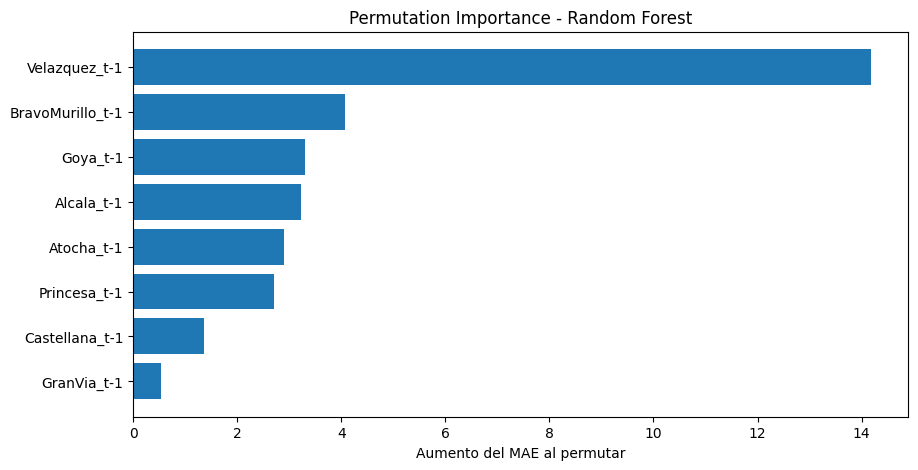

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Aumento del MAE al permutar")
plt.title("Permutation Importance - Random Forest")
plt.show()
